# Разработка A/B-тестирования и анализ результатов

**Контекст**

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

**Содержание проекта:**
  1. Содержание проекта, исходные данные;
  2. Анализ исторических данных;
  3. Подготовка к тесту;
  4. Мониторинг теста;
  5. Проверка результатов АВ-теста;
  6. Выводы

## Цель
Ваш: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## Описание данных

Даны три таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02..

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Работа с историческими данными (EDA)

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Загружаем датасет в тетрадку
sessions_history = pd.read_csv('..\..\Data (csv)\Файлы. Развлекательное приложение\sessions_project_history.csv')


# Выводим первые 5 строк для ознакомления
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [2]:
# Оценим объем даннных
sessions_history.shape

(435924, 10)

In [3]:
# Проверим наличие пропусков
sessions_history.isna().sum()

user_id              0
session_id           0
session_date         0
session_start_ts     0
install_date         0
session_number       0
registration_flag    0
page_counter         0
region               0
device               0
dtype: int64

In [4]:
# Проверим наличие полных дубликатов
sessions_history.duplicated().sum()

np.int64(0)

In [5]:
# Изучим типы данных датасета
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


### Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [6]:
# Для каждого пользователя рассчитаем количество уникальных сессuй
users_sessions = sessions_history.groupby('user_id')['session_id'].nunique().reset_index().sort_values(by='session_id',ascending=False)

# Выведем пользователя с наибольшим количеством сессий
top_user_id = users_sessions.iloc[0,0]

top_user = sessions_history.loc[sessions_history['user_id'] == top_user_id].sort_values(by='session_number')

top_user

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


**Первичный анализ показал:**
 - объем данных составляет 435924 строк и 10 столбцов;
 - данные в полях соответствуют описанию;
 - пропусков и дубликатов в данных нет;
 - поля, содержащие дату и время: `session_date`, `session_start_ts`, `install_date`, имеют тип данных object, а не datetime; остальные поля имеют корректный тип данных

#### Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом,  необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты примем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.


In [7]:
# Переведем поля с датой к соответствующему формату данных
for column in ['session_date','install_date','session_start_ts']:
    sessions_history[column] = pd.to_datetime(sessions_history[column])

# Добавим столбец с днем сессий
sessions_history['day'] = sessions_history['session_date'].dt.dayofyear

# Оставим только по одной строке сессии пользователя в день
unique_sessions = sessions_history.drop_duplicates(subset=['day','user_id'])

# Посчитаем количество активных уникальных пользователей в день
count_users = unique_sessions.groupby('day').agg({'user_id':'nunique',
                                                   'registration_flag':'sum'}).reset_index()
count_users.rename(columns = {'user_id':'amount_users',
                             'registration_flag':'amount_reg_users'},inplace=True)
count_users

,day,amount_users,amount_reg_users
0,223,3919,169
1,224,6056,336
2,225,8489,464
3,226,10321,625
4,227,14065,840
5,228,12205,916
6,229,11200,833
7,230,10839,860
8,231,12118,831
9,232,13514,1008


<Figure size 1200x800 with 0 Axes>

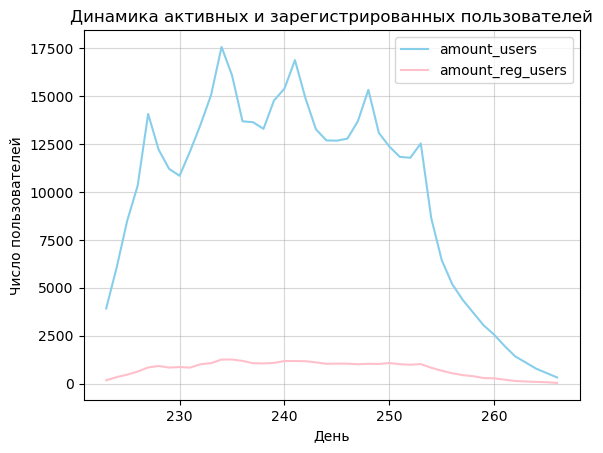

In [8]:
# Визуализируем динамику пользователей в абсолютных значениях
plt.figure(figsize=(12,8))

count_users.plot(kind='line',
                x = 'day',
                y=['amount_users','amount_reg_users'],
                legend = True,
                color = ['skyblue','pink'])
plt.title('Динамика активных и зарегистрированных пользователей')
plt.xlabel('День')
plt.ylabel('Число пользователей')
plt.grid(alpha=0.5)

plt.show()




По диаграмме видно, что динамика активности пользователей нестабильна, наблюдаются явные скачки и падения трафика. Под конец наблюдаемого периода активность пользователей резко снижается.
Динамика активности зарегистрированных пользователей более менее стабильна большую часть времени, что говорит о лояльности данной категории, однако на 254 день активность также снижается одновременно с активностью всех пользователей.

<Figure size 1200x800 with 0 Axes>

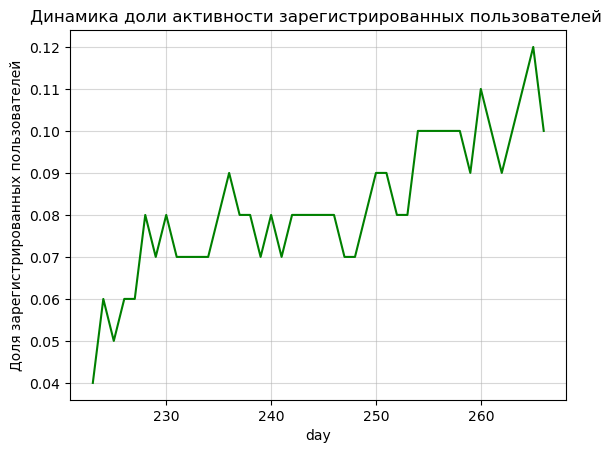

In [9]:
# Расчитаем долю зарегистрированных пользователей
count_users['share_reg_users'] = round(count_users['amount_reg_users'] / count_users['amount_users'],2)

plt.figure(figsize = (12,8))

count_users.plot(kind='line',
                x = 'day',
                y = 'share_reg_users',
                color = 'green',
                legend = False)
plt.title('Динамика доли активности зарегистрированных пользователей ')
plt.xlabel('day')
plt.ylabel('Доля зарегистрированных пользователей')
plt.grid(alpha=0.5)


plt.show()

В относительных значениях число активных зарегистрированных пользователей имеет растущий тренд: начиная с 0.04 показатель вырос до 0.09. Дальнейший рост показателя связан скорее с уменьшием общего числа пользователей.

#### Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. 

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.


In [10]:
# Отфильтруем данные, оставив только первые сессии
first_session_df = sessions_history[sessions_history.session_number == 1]

# Посчитаем количество первых сессий ля каждого значения количества просмотренных страниц
amount_first_sessions = first_session_df.groupby('page_counter', as_index = False)['session_number'].count().sort_values(by = 'session_number',ascending = False)

amount_first_sessions

,page_counter,session_number
2,3,50939
3,4,32739
1,2,32494
0,1,8978
4,5,8075
5,6,777
6,7,37


<Figure size 1200x800 with 0 Axes>

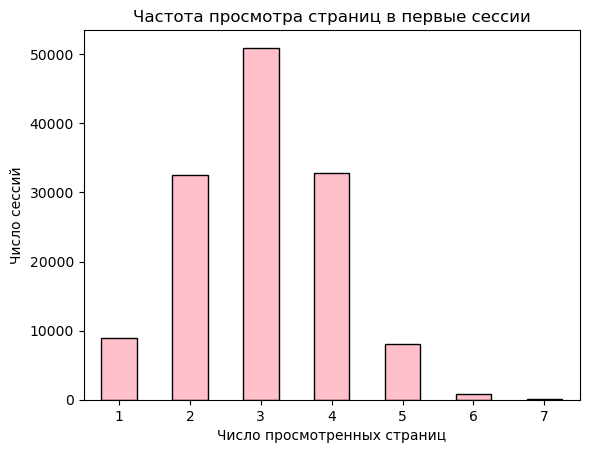

In [11]:
# Строим столбчатую диаграмму
plt.figure(figsize = (12,8))

amount_first_sessions.sort_values(by='page_counter').plot(kind = 'bar',
                          x = 'page_counter',
                          y = 'session_number',
                          legend = False,
                          color = 'pink',
                          edgecolor='black',
                          rot = 0)
plt.title('Частота просмотра страниц в первые сессии')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Число сессий')

plt.show()

Итак, чаще всего пользователи останавливаются на 3-й странице. Можно провести анализ, почему именно на этой странице заканчивается путь пользователя, чтобы в дальнейшем разработать пути завлечения на другие.

#### Доля пользователей, просмотревших более четырёх страниц
В качестве критерия удовлетворенности приложением определим  число первых сессий, в рамках которых пользователь просмотрел 4 и более страниц,  так как это может говорить об удовлетворённости контентом и алгоритмами рекомендаций.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей.

In [12]:
# Создадим доп. столбец,.в котором отразим, удовлетворяет ли сессия условию: число просмотренных страниц >= 4
sessions_history['good_session'] = 0
sessions_history.loc[(sessions_history['session_number']==1) &
                (sessions_history['page_counter']>=4), 'good_session'] = 1
# Отфильтруем датафрейм, оставив только первые сессии
first_sessions_df = sessions_history[sessions_history['session_number']==1]

# Посчитаем доли активных сессий по дням
share_good_sessions = first_sessions_df.groupby('day',as_index = False)['good_session'].mean().round(3).sort_values(by='day')

share_good_sessions.head()

,day,good_session
0,223,0.313
1,224,0.298
2,225,0.307
3,226,0.319
4,227,0.311


<Figure size 1200x800 with 0 Axes>

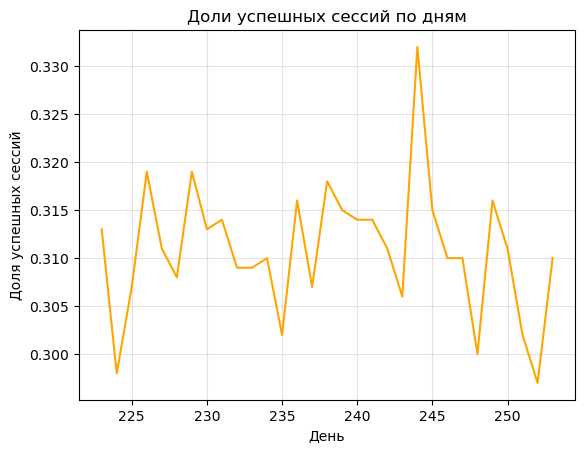

In [13]:
# Построим диаграмму с динамикой долей успешных первых сессий по дням

plt.figure(figsize = (12,8))

share_good_sessions.plot(kind = 'line',
                        x = 'day',
                        y = 'good_session',
                        legend = False,
                        color = 'orange')
plt.title('Доли успешных сессий по дням')
plt.xlabel('День')
plt.ylabel('Доля успешных сессий')
plt.grid(alpha = 0.35)

plt.show()


Можно увидеть, график имеет синусоидальную динамику: скачки чередуются с падениями показетеля. Пик приходится на 242-244 день со значением чуть более 33%. 

### Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [14]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [15]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1-beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03*p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [16]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(count_users['amount_users'].mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### Мониторинг А/В-теста

#### Проверка распределения пользователей

Пусть A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [17]:
# Загружаем датасет в тетрадку
sessions_test_part = pd.read_csv('..\..\Data (csv)\Файлы. Развлекательное приложение\sessions_project_test_part.csv')


# Выводим первые 5 строк для ознакомления
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [18]:
#Посчитаем количество пользователей в группах
users_by_groups = sessions_test_part.groupby('test_group')['user_id'].nunique()

users_by_groups

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [19]:
# Рассчитаем процентную разницу двух групп
A = users_by_groups.iloc[0]
B = users_by_groups.iloc[1]
P = round(100 * abs(A-B)/A,2)
print(f'Разница в размере между двумя группами {P}%')

Разница в размере между двумя группами 0.74%


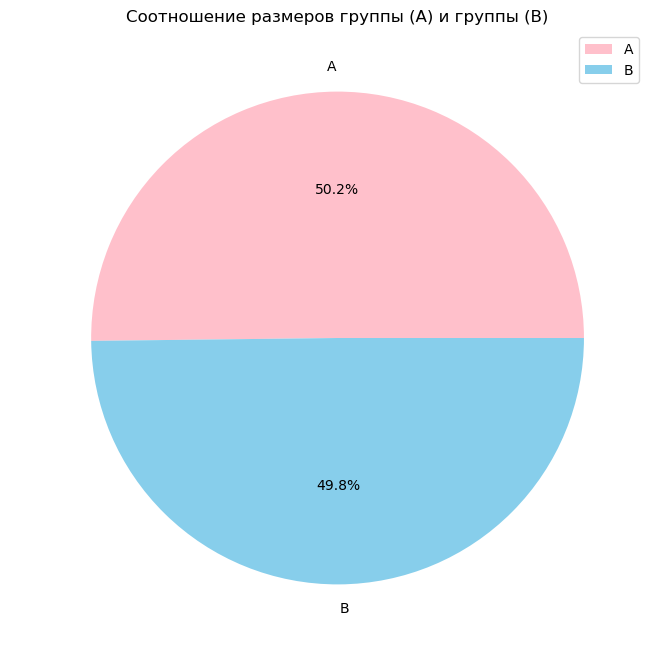

In [20]:
# Визуализируем разницу
plt.figure(figsize=(12,8))

users_by_groups.plot(kind='pie',
                     title='Соотношение размеров группы (А) и группы (В)',
                     legend=True,
                     colors=['pink','skyblue'],
                     ylabel=' ',
                     autopct='%.1f%%'
                     )
plt.show()

Разница в размере выборок для теста менее 1%, что в переделах допустимой погрешности

#### Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B

In [21]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = set(group_A).intersection(set(group_B))

intersection

set()

Итак, общих пользователей нет, значит, группы независимы

In [22]:
# Дополнительно проверим другим способом
check_independence = sessions_test_part.groupby('user_id')['test_group'].nunique().max()

check_independence

1

#### Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


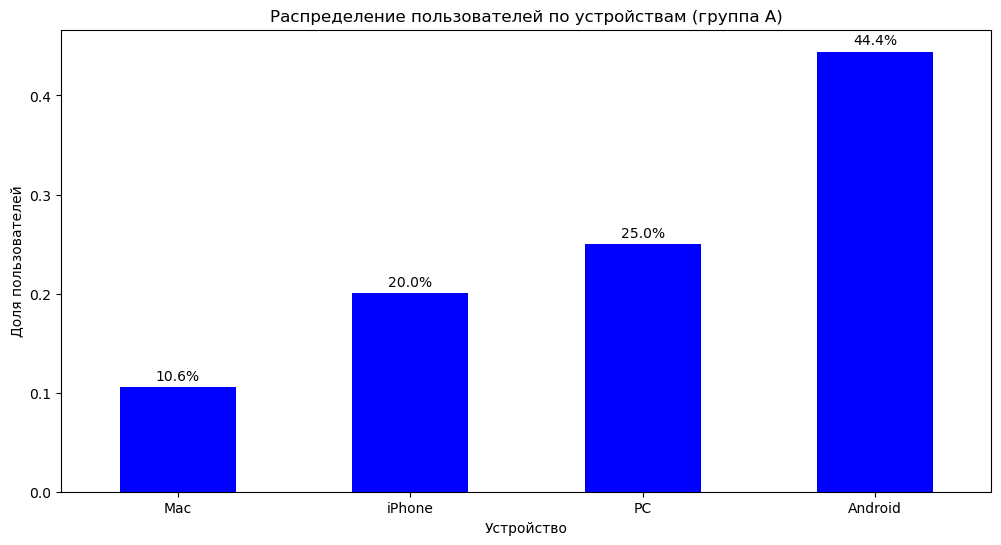

In [23]:
# Фильтруем по группе А
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']

# Считаем количество пользователей по девайсам
amount_devices_A = group_A.groupby('device',as_index=False)['user_id'].nunique().rename(columns={'user_id':'amount'})

# Считаем долю пользователей
amount_devices_A['share'] = amount_devices_A['amount'] / amount_devices_A['amount'].sum()


# Строим график
ax = amount_devices_A.sort_values(by='share').plot(kind='bar',
                      x = 'device',
                      y = 'share',
                      figsize=(12,6),
                      rot=0,
                      legend = False,
                      color='blue'
                     )
# Добавим подписи для каждого устройства
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')
    
plt.title('Распределение пользователей по устройствам (группа А)')
plt.xlabel('Устройство')
plt.ylabel('Доля пользователей')

plt.show()


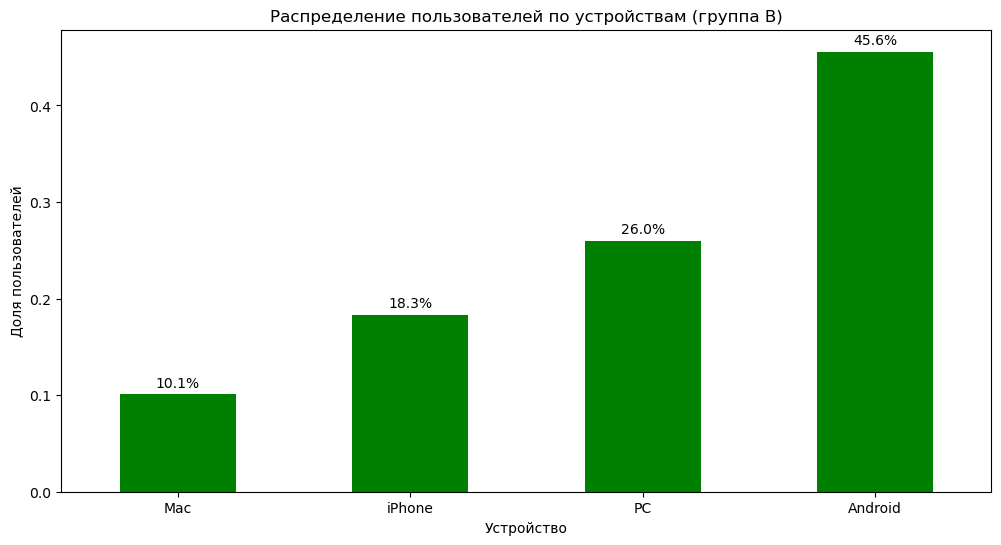

In [24]:
# Аналогично для группы В

group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

amount_devices_B = group_B.groupby('device',as_index=False)['user_id'].nunique().rename(columns={'user_id':'amount'})

amount_devices_B['share'] = amount_devices_B['amount'] / amount_devices_B['amount'].sum()


ax = amount_devices_B.sort_values(by='share').plot(kind='bar',
                      x = 'device',
                      y = 'share',
                      figsize=(12,6),
                      rot=0,
                      legend = False,
                      color='green'
                     )
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')


plt.title('Распределение пользователей по устройствам (группа В)')
plt.xlabel('Устройство')
plt.ylabel('Доля пользователей')

plt.show()

Разница в распределениях по каждому устройству между группами в пределах 2-х процентов - существенных отклонений в тесте быть не должно.

#### Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

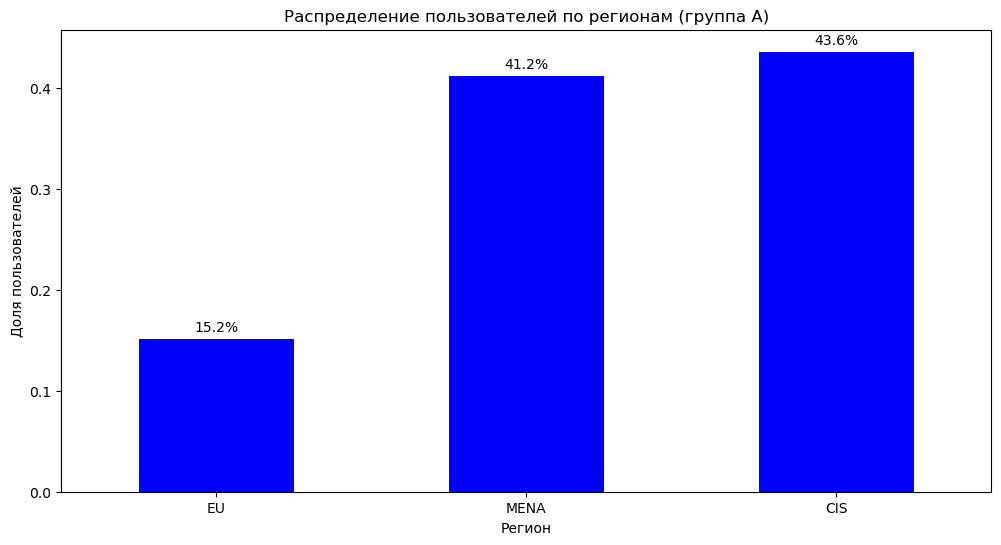

In [25]:

# Считаем количество пользователей по регионами
amount_region_A = group_A.groupby('region',as_index=False)['user_id'].nunique().rename(columns={'user_id':'amount'})

# Считаем долю пользователей
amount_region_A['share'] = amount_region_A['amount'] / amount_region_A['amount'].sum()


# Строим график
ax = amount_region_A.sort_values(by='share').plot(kind='bar',
                      x = 'region',
                      y = 'share',
                      figsize=(12,6),
                      rot=0,
                      legend = False,
                      color='blue'
                     )
# Добавим подписи для каждого региона
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')
    
plt.title('Распределение пользователей по регионам (группа А)')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')

plt.show()

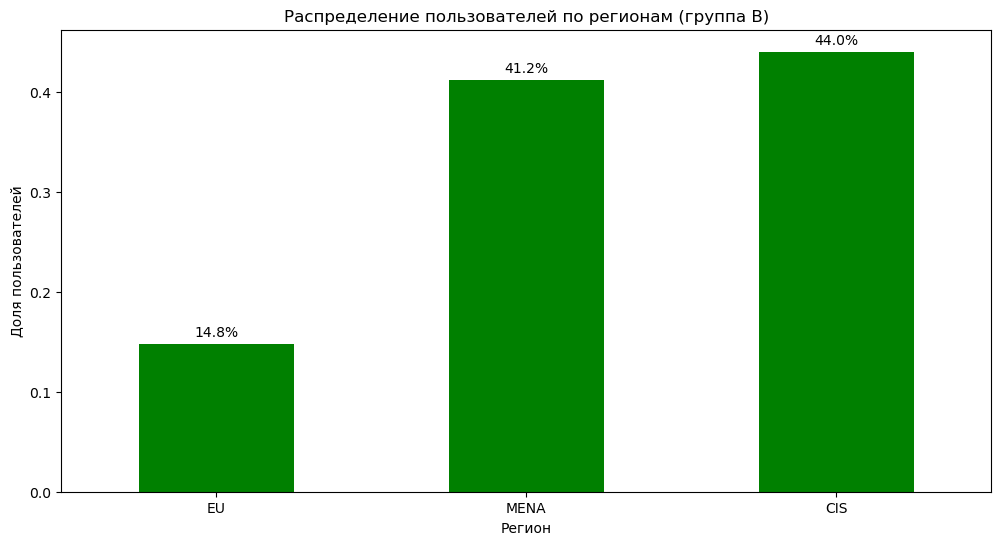

In [26]:
# Аналогично для группы В

# Считаем количество пользователей по регионами
amount_region_B = group_B.groupby('region',as_index=False)['user_id'].nunique().rename(columns={'user_id':'amount'})

# Считаем долю пользователей
amount_region_B['share'] = amount_region_B['amount'] / amount_region_B['amount'].sum()


# Строим график
ax = amount_region_B.sort_values(by='share').plot(kind='bar',
                      x = 'region',
                      y = 'share',
                      figsize=(12,6),
                      rot=0,
                      legend = False,
                      color='green'
                     )
# Добавим подписи для каждого региона
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')
    
plt.title('Распределение пользователей по регионам (группа В)')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')

plt.show()

В региональном отношении разница не более 0.4%

#### Вывод после проверки A/B-теста
Итак, проверка корректности проведения A/B теста показала:
 - количество пользователей в выборках примерно равное - разница составляет менее 1%
 - общих пользователей выборки не имеют, что говорит о независимости тестовой и контрольной групп
 - распределение пользователей по регионам и устройствам в тестовой и контрольной группах практически одинаковое: различия присутствуют но не превышают 2%.

Таким образом, мониторинг A/B-теста не выявил каких-либо нарушений

### Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### Получение результатов теста и подсчёт основной метрики

- Сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [27]:
# Загружаем датасет в тетрадку
sessions_test = pd.read_csv('..\..\Data (csv)\Файлы. Развлекательное приложение\sessions_project_test.csv')

# Выводим первые 5 строк для ознакомления
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [28]:
# Оценим размер групп

check = sessions_test.groupby('test_group')['user_id'].nunique()

check

test_group
A    15163
B    15416
Name: user_id, dtype: int64

In [29]:
# Найдем успешные сессии
sessions_test['good_session'] = 0

sessions_test.loc[sessions_test['page_counter']>=4,'good_session'] = 1


#### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, сформулируем нулевую и альтернативную гипотезы.

**Нулевая гипотеза H0**: доля успешных первых сессий не изменится, μ0=μ1

**Альтернативная гипотеза H1:** односторонняя вправо, доля успешных первых сессий увеличится, μ1=μ0

**Метрики**
- ключевая метрика - доля успешных первых сессий;
- прокси-метрика - время проведенное в приложении, активность пользователей, например, количество проставленных реакций под контентом;
- барьерная метрика - частота ошибок, сбоев, скорость загрузки приложения

#### Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.


In [30]:
# Отфильтруем датафрейм с тестом, оставив только первые сессии
first_sessions_test = sessions_test.loc[sessions_test.session_number == 1]

# Посчитаем долю успешных сессий для тестовой и контрольной групп
successful_session = first_sessions_test.groupby('test_group',as_index=False)['good_session'].mean().sort_values(by='test_group')

# Посчитаем разницу в долях успешных сессий

difference = successful_session.iloc[0,1] - successful_session.iloc[1,1]

display(f'Разница в ключевых метриках составляет {difference:.3}')

'Разница в ключевых метриках составляет 0.00105'

Значит, в контрольной группе (А) показатель больше, чем в тестовой (В). Далее следует проверить результат на значимость

#### Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости.

In [31]:
# Сохраним столбец с бинарным признаком для каждой группы в переменные
group_A = first_sessions_test.loc[first_sessions_test.test_group == 'A','good_session']

group_B = first_sessions_test.loc[first_sessions_test.test_group == 'B','good_session']

# Получим p-value
result = st.ttest_ind(
    group_A,
    group_B,
    alternative = 'less'
    )
print(f'р-значение: {result.pvalue}')

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу отвергнуть нельзя')

р-значение: 0.578349228097416
Нулевую гипотезу отвергнуть нельзя


Таким образом, изменение целевой метрики доля успешных сессий в тестовой группе статистически не значимо, следовательно, отвергнуть нулевую гипотезу мы не можем. Возможно, это связано с тем, что объемы выборок, взятые для теста, не достаточно большие.

### Вывод по результатам A/B-эксперимента

**Вывод**:

В работе проверялась эффективность внедрения новых алгоритмов подбора рекомендаций с помощью А/В тестирования.

Расчет объема выборок для теста дал результат 41040 пользователь для каждой группы. Исходя из ежедневной активности пользователей (более 9 тыс. уникальных пользователей в день) расчетная длительность теста составила 9 дней. 

Для проведения эксперимента случайным образом были отобраны пользователи в количестве чуть более 15000 человек в каждой группе, погрешность в размере между группами составила мнее 1%. Мониторинг А/В теста каких-либо нарушений не выявил: группы имеют схожее распределение по устройствам и регионам, зависимости между выборками нет. Единственный и существенный недочет теста - недостаточный объемом выборок

Результат теста определил уменьшение ключевой метрики (доля успешных сессий) в группе В как статистически НЕ значимый результат: p-значение оказалось больше уровня значимости (0.58 > 0.05).

Таким образом, отвергнуть нулевую гипотезу (доля успешных первых сессий в контрольной и тестовой группах равны) не представляется возможным. Это не значит, что изменений от нововведений нет, скорее всего, данных собрано не достаточно, поскольку для теста взято 15 тыс. пользователей вместо 41 тыс.